In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df=pd.read_csv('insurance.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [5]:
df.shape

(1340, 10)

In [6]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [7]:
pd.set_option("display.float_format", "{:.2f}".format)

In [8]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [9]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum().sum()

np.int64(8)

In [12]:
df.dropna(inplace=True)

In [13]:
df.shape

(1332, 10)

In [14]:
df.isna().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [15]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


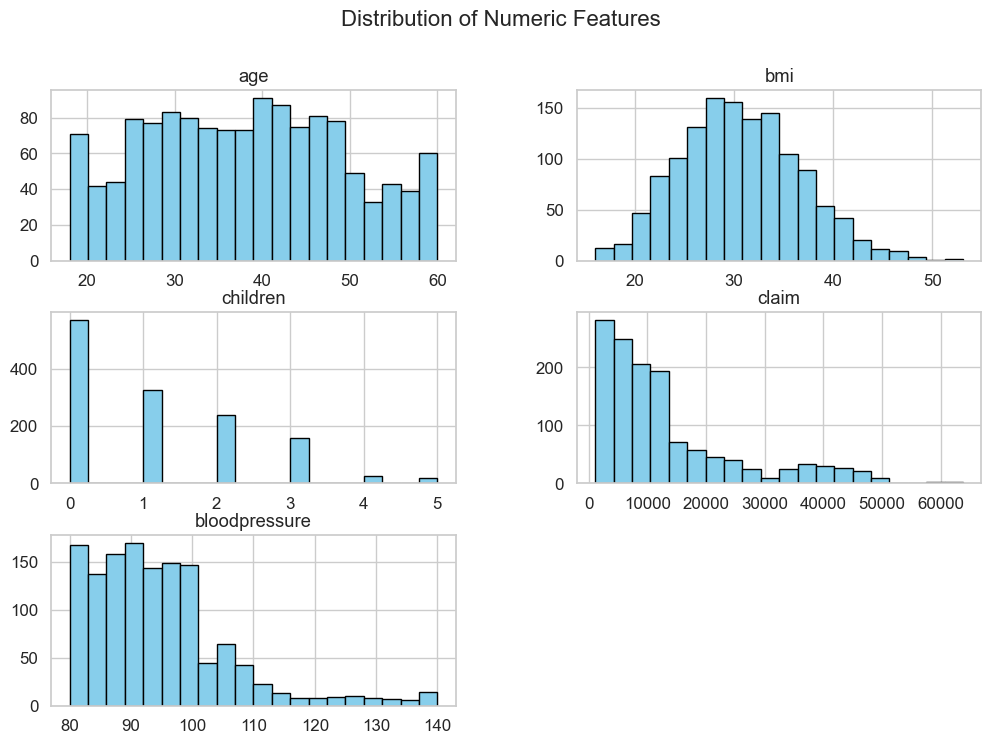

In [16]:
numeric_cols = ['age', 'bmi', 'children', 'claim', 'bloodpressure']
df[numeric_cols].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16)
plt.show()

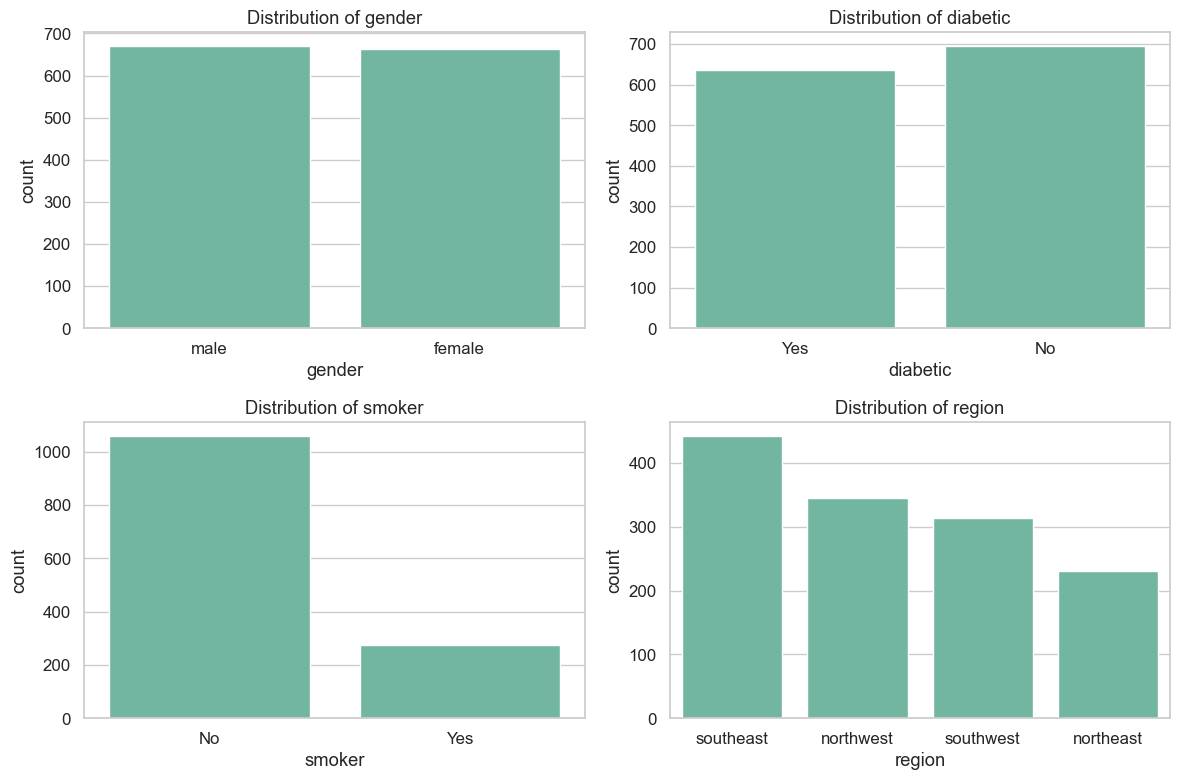

In [17]:
cat_cols=['gender','diabetic', 'smoker', 'region']
plt.figure(figsize=(12, 8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [18]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

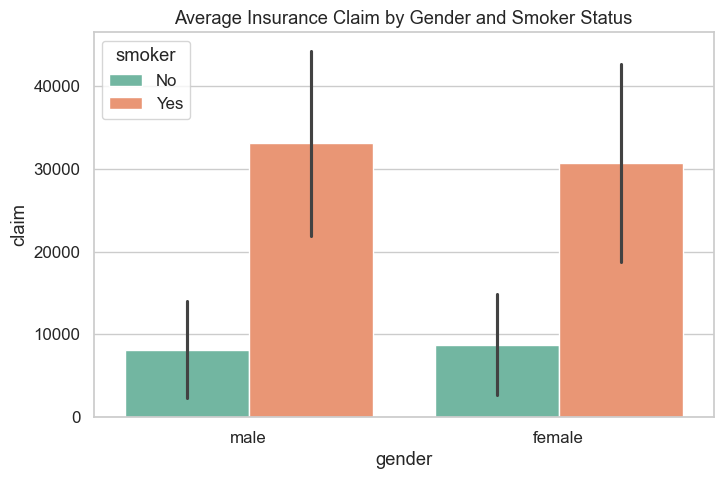

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="gender" , y="claim", hue="smoker", estimator = "mean",errorbar="sd")
plt.title("Average Insurance Claim by Gender and Smoker Status")
plt.show()

In [20]:
pivot_region_diabtic= df.groupby(["region", "diabetic"])["claim"].mean().unstack()


In [21]:
pivot_region_diabtic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


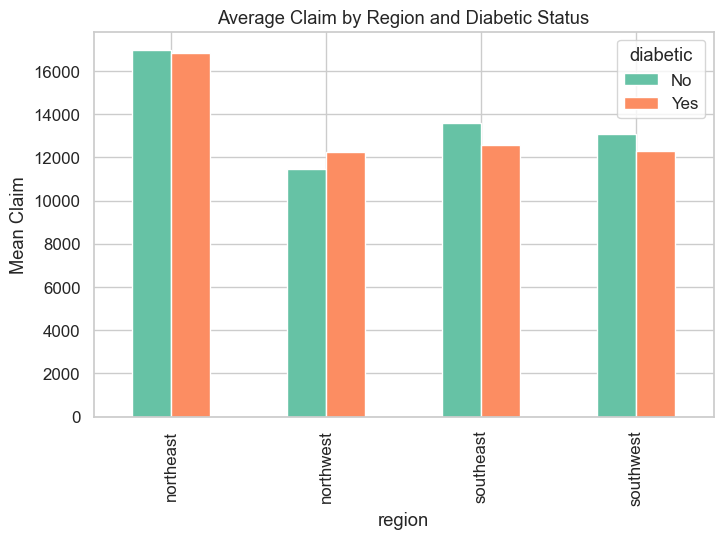

In [22]:
pivot_region_diabtic.plot(kind="bar", figsize=(8, 5))
plt.title("Average Claim by Region and Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()

In [23]:
pivot_table = pd.pivot_table(df, values='claim', index='region', columns='smoker', aggfunc='mean')

In [24]:
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [25]:
pivot_table = pd.pivot_table(df, values='claim', index='children', columns='diabetic', aggfunc='mean')

In [26]:
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [27]:
numeric_cols 

['age', 'bmi', 'children', 'claim', 'bloodpressure']

In [28]:
df[numeric_cols].corr()

,age,bmi,children,claim,bloodpressure
age,1.00,-0.04,-0.03,-0.03,-0.06
bmi,-0.04,1.00,0.01,0.20,0.14
children,-0.03,0.01,1.00,0.06,-0.03
claim,-0.03,0.20,0.06,1.00,0.53
bloodpressure,-0.06,0.14,-0.03,0.53,1.00


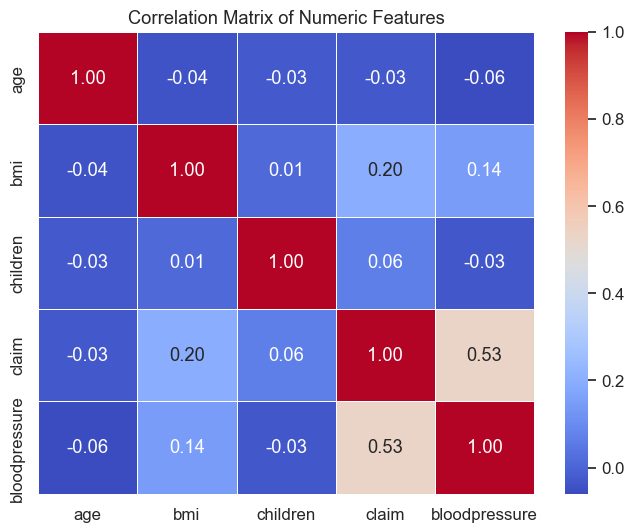

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

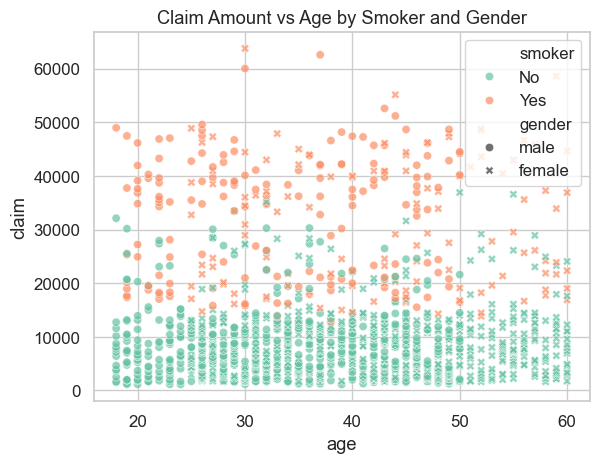

In [30]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker', style='gender', alpha=0.7)
plt.title('Claim Amount vs Age by Smoker and Gender')
plt.show()

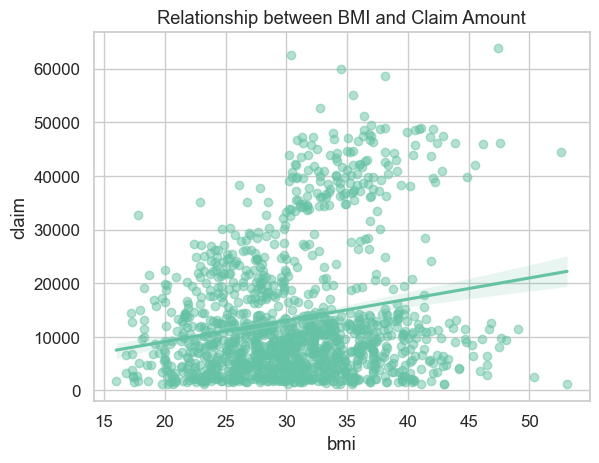

In [31]:
sns.regplot(data=df, x='bmi', y='claim', scatter_kws={'alpha':0.5})
plt.title('Relationship between BMI and Claim Amount')
plt.show()

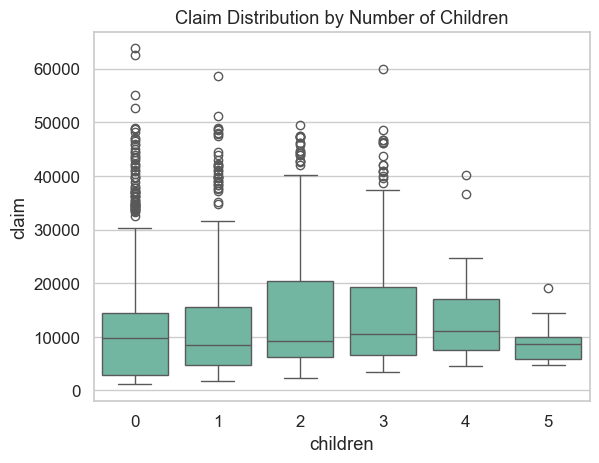

In [32]:
sns.boxplot(data=df, x='children', y='claim')
plt.title('Claim Distribution by Number of Children')
plt.show()

In [33]:
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 100], labels=['0-18', '19-35', '36-50', '51-65', '66+'])

In [34]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,36-50
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,19-35
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,19-35
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,19-35
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,19-35
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,36-50
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,51-65
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,19-35
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,36-50


In [35]:
df['age_group'].value_counts()

age_group
19-35    570
36-50    554
51-65    192
0-18      16
66+        0
Name: count, dtype: int64

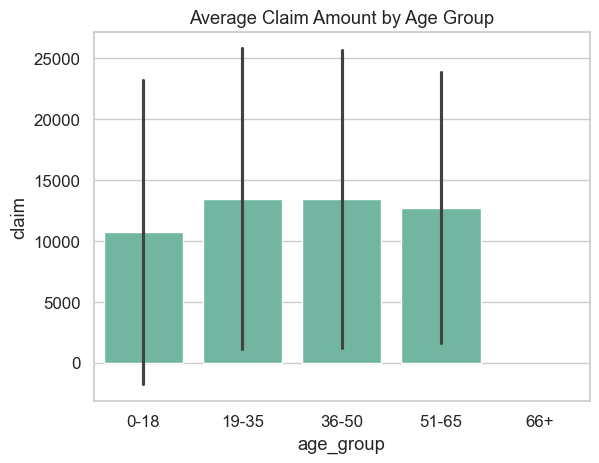

In [36]:
sns.barplot(data=df, x='age_group', y='claim', estimator='mean', errorbar='sd')
plt.title('Average Claim Amount by Age Group')
plt.show()

In [37]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [38]:
df['bmi_category'].value_counts()

bmi_category
Obese          693
Overweight     391
Normal         227
Underweight     21
Name: count, dtype: int64

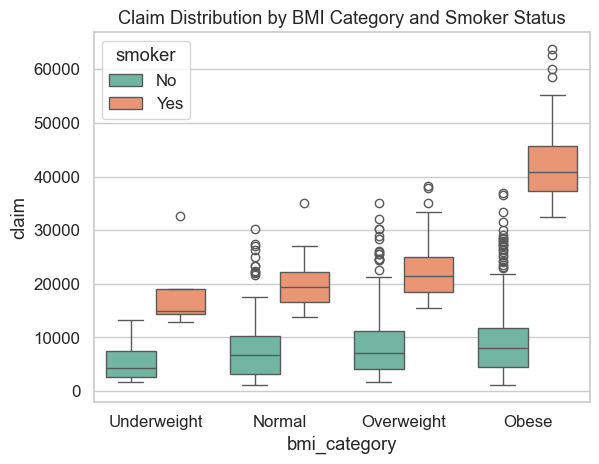

In [39]:
sns.boxplot(data=df, x='bmi_category', y='claim', hue='smoker')
plt.title('Claim Distribution by BMI Category and Smoker Status')
plt.show()

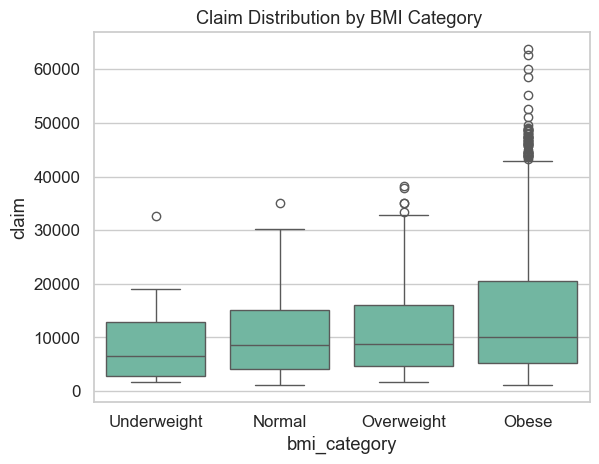

In [40]:
sns.boxplot(data=df, x='bmi_category', y='claim')
plt.title('Claim Distribution by BMI Category ')
plt.show()

In [41]:
region_status=df.groupby('region').aggregate(
    smoker_rate=('smoker', lambda x: (x == 'Yes').mean()*100),
    mean_claim=('claim', 'mean')
).reset_index()

In [42]:
region_status

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


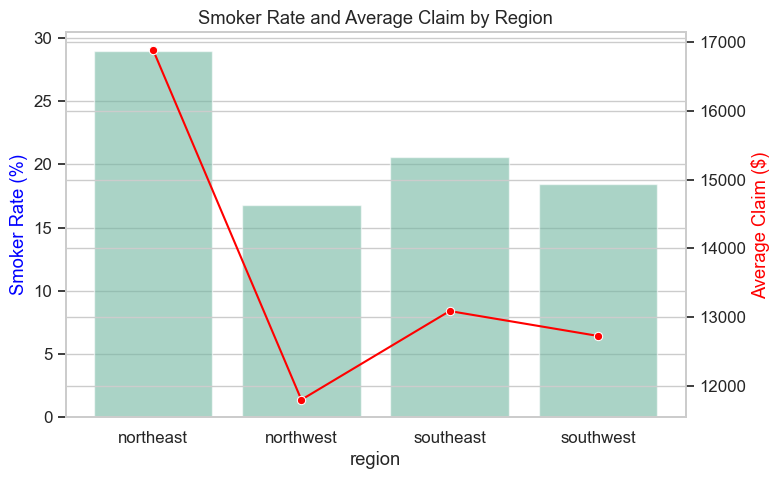

In [43]:
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(data=region_status, x='region', y='smoker_rate', ax=ax1, alpha=0.6)
ax2=ax1.twinx()
sns.lineplot(data=region_status, x='region', y='mean_claim', ax=ax2, color='red', marker='o')
ax1.set_ylabel('Smoker Rate (%)', color='blue')
ax2.set_ylabel('Average Claim ($)', color='red')
plt.title('Smoker Rate and Average Claim by Region')
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib


In [45]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [46]:
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic','children','smoker']]
y = df['claim']

In [47]:
X


,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [48]:
cat_cols = ['gender', 'diabetic', 'smoker']
label_encoders = {}

In [51]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f'label_encoder_{col}.pkl') 

C:\Users\lama_\AppData\Local\Temp\ipykernel_29676\1881895482.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\lama_\AppData\Local\Temp\ipykernel_29676\1881895482.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\lama_\AppData\Local\Temp\ipykernel_29676\1881895482.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [52]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [54]:
num_cols = ['age', 'bmi', 'bloodpressure', 'children']
scaler = StandardScaler()

In [60]:
X_train[num_cols]= scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [61]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [62]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [63]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


In [72]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor


import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor


In [67]:
def evaluate_model(model, X_test, X_train ,y_train,y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse=np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2" : r2, "MAE": mae, "RMSE": rmse}

In [69]:
results = {}

In [74]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = evaluate_model(lr, X_test, X_train ,y_train,y_test)

print("Linear Regression Results Model trained", results['Linear Regression'])


best_poly_model = None
best_poly_score = -np.inf
for degree in range(2, 5):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train)
    
    score = evaluate_model(lr_poly, X_test_poly, X_train_poly ,y_train,y_test)['R2']
    
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (lr_poly, degree, poly)


lr_poly, degree, poly = best_poly_model

results[f"Polynomial Regression (degree {degree})"] = evaluate_model(
    lr_poly,
    poly.transform(X_test),
    poly.transform(X_train),
    y_train,
    y_test
)

print("Polynomial Regression Results Model trained")



rf= RandomForestRegressor()

rf_params = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


rf_grid = GridSearchCV(rf, rf_params, cv=3, n_jobs=-1, scoring='r2', verbose=0)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_

results['Random Forest'] = evaluate_model(rf_best, X_test, X_train ,y_train,y_test)

print("Random Forest Results Model trained with best parameters:", rf_grid.best_estimator_)


svr= SVR()
svr_params = {

    'kernel': ['rbf', 'poly','linear'],
    'C': [ 1, 10, 50],
    'epsilon': [0.1, 0.2, 0.5],
    'degree': [2, 3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, n_jobs=-1, scoring='r2', verbose=0)

svr_grid.fit(X_train, y_train)
best_svr=svr_grid.best_estimator_
results['SVR'] = evaluate_model(best_svr, X_test, X_train ,y_train,y_test)

print("SVR Results Model trained with best parameters:", svr_grid.best_estimator_)

xgb= XGBRegressor(objective='reg:squarederror', random_state=42)

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01,0.05 ,0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, n_jobs=-1, scoring='r2', verbose=0)

xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
results['XGBoost'] = evaluate_model(best_xgb, X_test, X_train ,y_train,y_test)
print("XGBoost Results Model trained with best parameters:", xgb_grid.best_estimator_)



Linear Regression Results Model trained {'R2': 0.7080198104724322, 'MAE': 4828.048619985543, 'RMSE': np.float64(6255.636549738532)}
Polynomial Regression Results Model trained
Random Forest Results Model trained with best parameters: RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200)
SVR Results Model trained with best parameters: SVR(C=50, degree=2, epsilon=0.5, kernel='linear')
XGBoost Results Model trained with best parameters: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_

In [75]:
results

{'Linear Regression': {'R2': 0.7080198104724322,
  'MAE': 4828.048619985543,
  'RMSE': np.float64(6255.636549738532)},
 'Polynomial Regression (degree 3)': {'R2': 0.8044290290728311,
  'MAE': 3977.2322430089143,
  'RMSE': np.float64(5119.729447865235)},
 'Random Forest': {'R2': 0.8347429387934276,
  'MAE': 3612.767663219559,
  'RMSE': np.float64(4706.248206504404)},
 'SVR': {'R2': 0.5877075087655323,
  'MAE': 5167.219710380719,
  'RMSE': np.float64(7433.571585675551)},
 'XGBoost': {'R2': 0.8387323898976269,
  'MAE': 3573.5429644341057,
  'RMSE': np.float64(4649.094675343186)}}

In [76]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='R2', ascending=False)   

In [77]:
results_df

,R2,MAE,RMSE
XGBoost,0.84,3573.54,4649.09
Random Forest,0.83,3612.77,4706.25
Polynomial Regression (degree 3),0.80,3977.23,5119.73
Linear Regression,0.71,4828.05,6255.64
SVR,0.59,5167.22,7433.57


In [94]:
models={
    'Linear Regression': lr,
    'Polynomial Regression': lr_poly,
    'Random Forest': rf_best,
    'SVR': best_svr,
    'XGBoost': best_xgb
}

In [95]:
best_r2 = results_df['R2'].max()

In [96]:
best_r2

0.8387323898976269

In [97]:
top_model = results_df[results_df['R2'] == best_r2]

In [98]:
top_model

,R2,MAE,RMSE
XGBoost,0.84,3573.54,4649.09


In [101]:
best_model = models[top_model.index[0]]

In [102]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [105]:
joblib.dump(best_model, 'best_model.pkl')
print(f"Best model selected: {top_model.index[0]} with R2: {best_r2:.4f}")

Best model selected: XGBoost with R2: 0.8387
